## 0. Импорты и загрузка данных

In [ ]:
!pip install optuna --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
import time
from statsmodels.tsa.seasonal import seasonal_decompose
from lightgbm import LGBMRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sales_train_evaluation = pd.read_csv("sales_train_evaluation.csv")
calendar = pd.read_csv("calendar.csv")
sell_prices = pd.read_csv("sell_prices.csv")

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 1. Вводная информация о кейсе

В полной версии проекта планируется создание системы квантильного прогнозирования спроса для всей товарной матрицы распределительного центра. Она будет динамически подбирать уровень перцентиля в зависимости от срока годности, маржинальности и риска порчи каждого SKU, автоматически агрегируя заказы на уровне склада.

Однако для этапа прототипирования мы сознательно сужаем скоуп до **одной категории, одного сценария и одной модели монетизации**.

Категория скоропортящихся товаров обладает наибольшей «ценой ошибки», поэтому прототип фокусируется именно на ней.

---

**Гипотезы**:
**Техническая гипотеза**
Если мы предлагаем **инструмент квантильного прогнозирования спроса с персентилем, оптимизированным под минимизацию бизнес-потерь** *(Продукт A)*  
для **менеджеров по пополнению запасов категории «скоропортящаяся продукция»** *(Сегмент B)*
в сценарии **еженедельного планирования заказов на 7 дней вперёд** *(Сценарий C)*,  
то мы получим **снижение симулированных бизнес-потерь от порчи на ≥10%** *(Метрика D ≥ E)*  
в течение **4 недель бэктеста на исторических данных M5** *(Время T)*,
потому что **явное смещение прогноза вниз через выбор определенного перцентиля минимизирует риск over-forecasting, в отличие от традиционных точечных прогнозов, которые штрафуют ошибки «вверх» и «вниз» одинаково, игнорируя разную экономическую цену этих ошибок для скоропортящихся товаров**.

> *Примечание: Целевое значение ≥10% является гипотетическим ориентиром на основе отраслевых бенчмарков. Фактический порог успеха будет уточнён после EDA и анализа распределения ошибок.*

**Бизнес-модельная гипотеза**
Если мы предлагаем **инструмент прогнозирования спроса, оптимизированный под минимизацию бизнес-потерь** *(Продукт A)*
для **менеджеров по пополнению запасов категории «скоропортящаяся продукция»** *(Сегмент B)*
в сценарии **еженедельного планирования заказов на 7 дней вперёд** *(Сценарий C)*,
то мы получим **≥30% конверсию из демо в запрос на пилот** *(Метрика D ≥ E)*  
в течение **2 недель после показа демо** *(Время T)*,  
потому что **менеджер видит прямую связь между прогнозом и экономией в денежном эквиваленте, а не только техническую точность, что снижает барьер принятия решения о тестировании**.

> **Источники**:
> - Бизнес-анализ: [`homework_1/business_analysis.md`](../homework_1/business_analysis.md)
> - Прототип и гипотезы: [`homework_2/prototype.md`](../homework_2/prototype.md)
---

## 2. Загрузка и минимальная очистка данных

Полный пайплайн формирования сабсета описан в [ДЗ №4: data_report.md](../homework_4/data_report.md).  
В этом ноутбуке воспроизводим **минимально необходимую предобработку** для baseline.

In [ ]:
sales_train_evaluation.head(3)

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1


In [ ]:
calendar.head(3)

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0


In [ ]:
sell_prices.head(3)

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26


In [ ]:
# формирую сабсет по критериям: один магазин и скоропортящиеся категории
subset_sales = sales_train_evaluation[(sales_train_evaluation['store_id'] == 'CA_1') &
                       ((sales_train_evaluation['dept_id'] == 'FOODS_1') |
                       (sales_train_evaluation['dept_id'] == 'FOODS_2'))]
days_cols = [col for col in sales_train_evaluation.columns if col.startswith('d_')]
subset_long = subset_sales.melt(
    id_vars=['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    value_vars=days_cols,
    var_name='d',
    value_name='sales'
)
calendar_subset = calendar[
    calendar['d'].isin(subset_long['d'].unique())
][[
    'd', 'wday', 'month', 'year',
    'event_name_1', 'event_type_1',
    'event_name_2', 'event_type_2',
    'snap_CA', 'wm_yr_wk'
]].copy()
calendar_subset.head()

# merge sales и calendar (по ключу 'd')
df_merged = subset_long.merge(calendar_subset, on='d', how='left')

# подготовка и merge с ценами
prices_subset = sell_prices[
    (sell_prices['store_id'] == 'CA_1') &
    (sell_prices['item_id'].isin(subset_sales['item_id']))
][['store_id', 'item_id', 'wm_yr_wk', 'sell_price']].copy()
df_final = df_merged.merge(prices_subset, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

# проверим итоговый результат
print(f"Итоговый размер датасета: {df_final.shape}")
print(f"Пропуски в sales: {df_final['sales'].isna().sum()}")
print(f"Пропуски в sell_price: {df_final['sell_price'].isna().sum()}")
del subset_sales, subset_long, calendar_subset, df_merged, prices_subset
df_final.head()

Итоговый размер датасета: (1191774, 17)
Пропуски в sales: 0
Пропуски в sell_price: 211715


,item_id,dept_id,cat_id,store_id,state_id,d,sales,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,wm_yr_wk,sell_price
0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,1,1,2011,NaN,NaN,NaN,NaN,0,11101,2.00
1,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,d_1,0,1,1,2011,NaN,NaN,NaN,NaN,0,11101,7.88
2,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,d_1,0,1,1,2011,NaN,NaN,NaN,NaN,0,11101,2.88
3,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_1,0,1,1,2011,NaN,NaN,NaN,NaN,0,11101,NaN
4,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,d_1,3,1,1,2011,NaN,NaN,NaN,NaN,0,11101,2.94


В реальности цена товара не меняется ежедневно. Если в системе нет цены на конкретный день, логично предположить, что действует последняя известная цена. В sell_price 17.8% пропусков - 211 715 / 1 191 774. Систематические пропуски - не случайный шум, а ввод/вывод товаров. Бороться с пропусками буду с помощью Forward-fill и Backward-fill - они не внесут смещения


In [ ]:
# Forward-fill: последняя известная цена действует вперёд
df_final["sell_price"] = df_final.groupby(["store_id", "item_id"])["sell_price"].ffill()

# Backward-fill: если товар начался с NaN - использовать первую известную цену назад
df_final["sell_price"] = df_final.groupby(["store_id", "item_id"])["sell_price"].bfill()

# проверяем, что пропусков в столбцах sales и sell_price не осталось
print(f"Пропуски в sales: {df_final['sales'].isna().sum()}")
print(f"Пропуски в sell_price: {df_final['sell_price'].isna().sum()}")

Пропуски в sales: 0
Пропуски в sell_price: 0


## 3. EDA

Полный анализ проведён в рамках [ДЗ №4: data_report.md](../homework_4/data_report.md).  
Ниже — ключевые выводы, определяющие выбор baseline и стратегию улучшения:

* **Распределение таргета:** 62.1% нулевых продаж, медиана = 2.0, среднее = 3.27, правый хвост с выбросами до 94 ед. - требуются метрики, устойчивые к zero-inflation и асимметрии (MAE, Quantile Loss);
* **Сезонность:** Чёткий 7-дневный цикл с амплитудой ±1.5 ед. - обосновывает использование `Seasonal Naive` (лаг 7) как сильного эвристического baseline;
* **Внешние факторы:** SNAP-дни увеличивают спрос на 12.5% - сохраняем этот сигнал для улучшенной модели, чтобы baseline остался «чистым» и интерпретируемым;
* **Зрелость данных:** История продаж 200–1500 дней у большинства SKU, отсутствие массового ввода/вывода - временной сплит надёжен, риск дрейфа концепта минимален;
* **Холодный старт:** 0% товаров с <50 днями продаж - иерархический пуллинг не требуется, можно безопасно обучать на уровне `item_id`.

> **Вывод для baseline:** Исходя из знания о недельном цикле закупок, в качестве точки отсчёта выбираем **Seasonal Naive** (`y_t = y_(t-7)`) - не требует обучения, устойчив к шуму и задает честный порог, который должна превзойти ML-модель. Затем обучим Linear Regression и базовый LightGBM. Для улучшенной модели предусмотрены небольшой feature engineering, использование внешних ковариат и поиск оптимальных гиперпараметров на валидации. Модель будем использовать ту, что покажет лучшее качество - предположительно это будет LightGBM.

Для оценки используем метрику **MAE** (устойчива к выбросам).
Начиная с базового LightGBM, применяем **квантильную функцию потерь** (`alpha=0.5`), которая минимизирует MAE напрямую и устойчива к асимметричному распределению ошибок. На этапе финального улучшения подключим сетку квантилей `α ∈ [0.3; 0.5]` для проверки продуктовой гипотезы об асимметрии бизнес-потерь.




Распределение sales:
count    1.191774e+06
mean     1.240023e+00
std      2.972005e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      9.400000e+01
Name: sales, dtype: float64


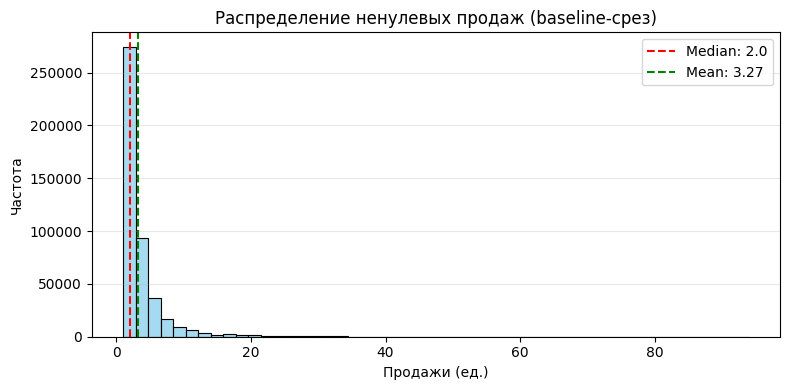

In [ ]:
# статистика таргета
print("Распределение sales:")
print(df_final['sales'].describe())

# гистограмма ненулевых продаж
plt.figure(figsize=(8, 4))
nonzero = df_final[df_final['sales'] > 0]['sales']
sns.histplot(nonzero, bins=50, kde=False, color='skyblue', edgecolor='black')
plt.axvline(nonzero.median(), color='red', linestyle='--', label=f'Median: {nonzero.median():.1f}')
plt.axvline(nonzero.mean(), color='green', linestyle='--', label=f'Mean: {nonzero.mean():.2f}')
plt.title('Распределение ненулевых продаж (baseline-срез)')
plt.xlabel('Продажи (ед.)')
plt.ylabel('Частота')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Обучение Baseline

### Реализация Baseline и первичное улучшение:
- 3 простых baseline, как честная точка отсчёта:
  - **Эвристика** `Seasonal Naive` (лаг 7);
  - **Простой ML** `Linear Regression` (только lag_7);
  - **Нелинейный ML** `LightGBM` базовый (только lag_7, квантильный loss) как честная точка отсчёта;
- реализация 1 усложнённой модели: `LightGBM Quantile (α=0.5)` (лаги, wday, snap_CA, цена) c feature engineering и оптимизацией гиперпараметров через Optuna.

### Мысли по будущему финальному улучшению модели:
- проверка основной продуктовой гипотезы - поиск оптимального квантиля α ∈ [0.3; 0.5] через минимизацию асимметричных бизнес-потерь;
- продвинутый feature engineering: взаимодействия признаков, ценовые бинны, флаги жизненного цикла товара, иерархические агрегаты;
- возможное улучшение архитектуры (двухэтапные модели)

Из EDA можно вспомнить о event_name_2 - всего 5 дней за 5 лет имеют два события одновременно

In [ ]:
df_final[df_final['event_name_2'].notna()]

,item_id,dept_id,cat_id,store_id,state_id,d,sales,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,wm_yr_wk,sell_price
52190,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_86,0,2,4,2011,OrthodoxEaster,Religious,Easter,Cultural,0,11113,2.00
52191,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,d_86,1,2,4,2011,OrthodoxEaster,Religious,Easter,Cultural,0,11113,7.88
52192,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,d_86,0,2,4,2011,OrthodoxEaster,Religious,Easter,Cultural,0,11113,2.88
52193,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_86,0,2,4,2011,OrthodoxEaster,Religious,Easter,Cultural,0,11113,1.78
52194,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,d_86,7,2,4,2011,OrthodoxEaster,Religious,Easter,Cultural,0,11113,2.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757671,FOODS_2_395,FOODS_2,FOODS,CA_1,CA,d_1234,1,2,6,2014,NBAFinalsEnd,Sporting,Father's day,Cultural,0,11420,3.96
757672,FOODS_2_396,FOODS_2,FOODS,CA_1,CA,d_1234,0,2,6,2014,NBAFinalsEnd,Sporting,Father's day,Cultural,0,11420,2.98
757673,FOODS_2_397,FOODS_2,FOODS,CA_1,CA,d_1234,1,2,6,2014,NBAFinalsEnd,Sporting,Father's day,Cultural,0,11420,2.98
757674,FOODS_2_398,FOODS_2,FOODS,CA_1,CA,d_1234,0,2,6,2014,NBAFinalsEnd,Sporting,Father's day,Cultural,0,11420,2.36


Так и в сабсете можно заметить,что только 2456 строки из 1191774 обладают этим признаком. Это экстремально редкий признак, а значит можно удалить эти столбцы

In [ ]:
df_final.drop(columns=['event_name_2', 'event_type_2'], inplace=True)
df_final.shape

(1191774, 15)

Итак, на данном этапе нужно получить честную точку отсчёта. Простые модели (Seasonal Naive, Linear Regression, LightGBM) используют только лаги (lag_7) и тренд. Это позволяет зафиксировать нижнюю границу качества (floor performance).

Я предлагаю намеренно исключить признаки событий из простых моделей. Их добавление требует предобработки (заполнение NaN, One-Hot Encoding), что усложняет пайплайн. Базовые сильные признаки (`lag_7`, `wday`, `snap_CA`, `sell_price`) оставлю для усложненной модели (LightGBM + Optuna), чтобы наглядно продемонстрировать прирост метрики за счёт Feature Engineering. Без признаков событий получится измерить чистый вклад временных паттернов, а любое улучшение метрик в сложной модели будет означать, что мы успешно извлекли сигнал из событий и цен.

In [ ]:
df_final['d_num'] = df_final['d'].str.replace('d_', '').astype(int)
df_final = df_final.sort_values(['item_id', 'd_num']).reset_index(drop=True)

df_final['lag_7'] = df_final.groupby('item_id')['sales'].shift(7)
train_end, val_start, val_end, test_start = 1500, 1501, 1700, 1701

train_val_mask = df_final['d_num'] <= val_end
test_mask = df_final['d_num'] >= test_start

df_train = df_final[train_val_mask].copy()
df_test = df_final[test_mask].copy()

print(f"Размеры выборок:\nTrain={len(df_train)}, \nTest={len(df_test)}")

df_test_naive = df_test.dropna(subset=['lag_7']).copy()

start_time = time.time()
mae_naive = mean_absolute_error(df_test_naive['sales'], df_test_naive['lag_7'])
time_naive = time.time() - start_time

print(f"Seasonal Naive (lag=7) MAE: {mae_naive:.3f}")
print(f"Время инференса: {time_naive:.4f} сек")

Размеры выборок:
Train=1043800, 
Test=147974
Seasonal Naive (lag=7) MAE: 1.331
Время инференса: 0.1330 сек


### Результат работы Seasonal Naive (lag=7)

**Метрика**: MAE = 1.331  
**Время инференса**: 0.1330 сек

Результат получился хороший из-за сильной недельной сезонности. В ДЗ №4 мы статистически подтвердили (через ACF с 95% доверительным интервалом), что лаги 7, 14, 21, 28 значимы для товаров с разным уровнем спроса. `Seasonal Naive` идеально эксплуатирует этот паттерн: `y_t = y_{t-7}`. Также эвристика не "переобучается" на редких пиках (до 94 ед./день) и не размывает сигнал усреднением — она просто повторяет прошлую неделю.

Получилась **честная и сильная точку отсчёта**. Любая ML-модель должна превзойти MAE = 1.331, чтобы доказать свою ценность. Если LightGBM покажет сопоставимый результат — это важный инсайт: задача хорошо решается эвристикой, и усложнение архитектуры не всегда окупается.

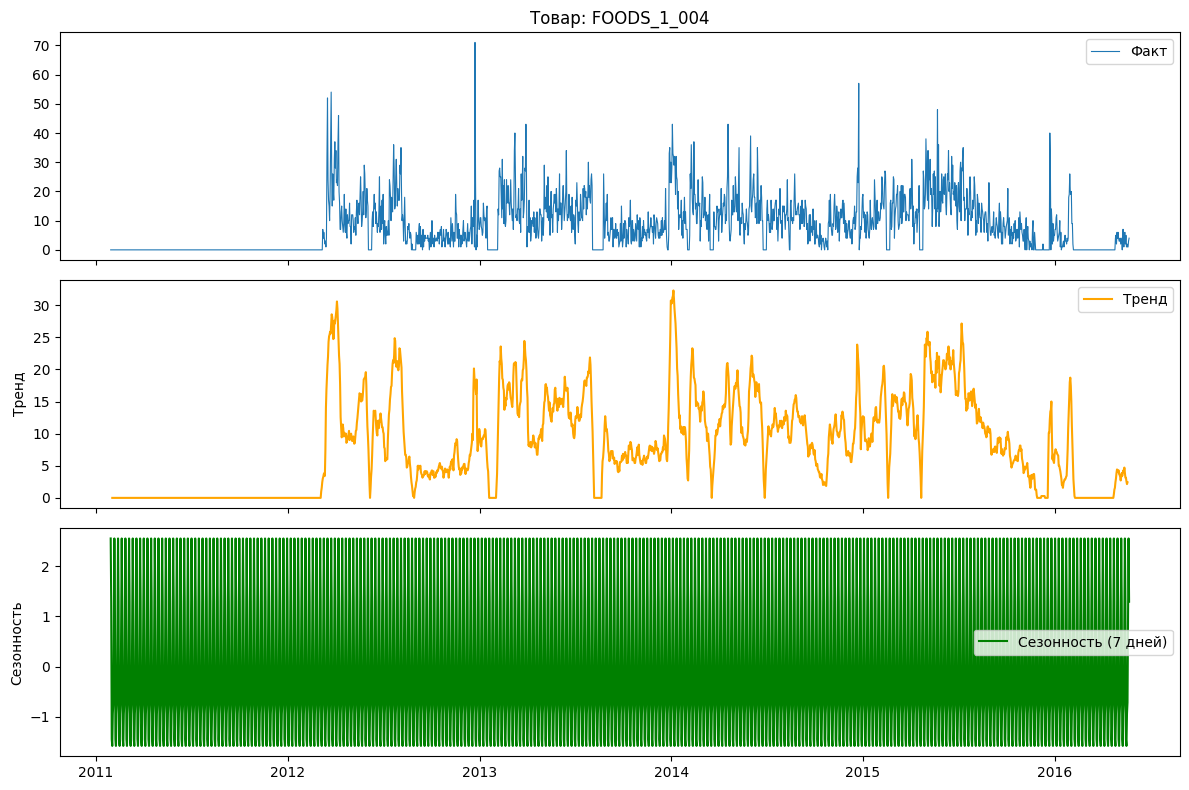

In [ ]:
# сумма продаж по каждому item_id
item_sales = df_final.groupby('item_id')['sales'].sum()
threshold = item_sales.quantile(0.75)
sample_item = item_sales[item_sales > threshold].index[0]

# формирование временного ряда
ts_df = df_final[df_final['item_id'] == sample_item].copy()
ts_df['date'] = pd.to_datetime(
    ts_df['d'].str.replace('d_', '').astype(int) - 1,
    unit='D', origin='2011-01-29'
)
ts = ts_df.set_index('date')['sales'].asfreq('D')  # гарантируем ежедневную частоту

# декомпозиция
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
decomp = seasonal_decompose(ts, model='additive', period=7)

ax[0].plot(ts, label='Факт', linewidth=0.8)
ax[0].set_title(f'Товар: {sample_item}')
ax[0].legend()

ax[1].plot(decomp.trend, label='Тренд', color='orange')
ax[1].set_ylabel('Тренд'); ax[1].legend()

ax[2].plot(decomp.seasonal, label='Сезонность (7 дней)', color='green')
ax[2].set_ylabel('Сезонность'); ax[2].legend()
plt.tight_layout()
plt.show()

На примере `FOODS_1_004` (см. график из EDA) видно, что товар имеет **жизненный цикл**:
- **Период 1 (2011)**: Товар не продавался (0 продаж)
- **Период 2 (2012–2015)**: Активные продажи с колебаниями 0–70 ед./день
- **Период 3 (2016)**: Спрос упал, товар выводился из ассортимента

Если мы обучаем LR на всём датасете, модель видит:
- для дней `d_1`–`d_300`: `lag_7 = 0` → `sales = 0`
- для дней `d_301+`: `lag_7` варьируется, `sales` тоже

Но для Baseline важна минимальная предобработка, seasonal naive работает на этих же данных, а товар может долго не продаваться - поэтому периоды без продаж оставим. Если LR проиграет — это покажет, что задача нелинейна.

In [ ]:
# удаляем только строки, где лаг физически не существует
# (первые 7 дней каждого товара после сортировки)

train_val_mask = df_final['d_num'] <= val_end
test_mask = df_final['d_num'] >= test_start

df_lr = df_final.dropna(subset=['lag_7', 'sales']).copy()

train_val_lr = df_lr[df_lr['d_num'] <= val_end]
test_lr = df_lr[df_lr['d_num'] >= test_start]

print(f"LR Train and Val: {len(train_val_lr)}, Test: {len(test_lr)}")

X_train = train_val_lr[['lag_7']]
y_train = train_val_lr['sales']
X_test = test_lr[['lag_7']]
y_test = test_lr['sales']

start_time = time.time()
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
preds_lr = lr_model.predict(X_test)
time_lr = time.time() - start_time

mae_lr = mean_absolute_error(y_test, preds_lr)

print(f"Linear Regression (lag_7 only) MAE: {mae_lr:.3f}")
print(f"Время обучения и инференса: {time_lr:.3f} сек")

print(f"Коэффициенты модели:")
print(f"intercept = {lr_model.intercept_:.3f}")
print(f"coef(lag_7) = {lr_model.coef_[0]:.3f}")

LR Train+Val: 1039502, Test: 147974
Linear Regression (lag_7 only) MAE: 1.291
Время обучения и инференса: 0.084 сек
Коэффициенты модели:
intercept = 0.429
coef(lag_7) = 0.650


Можно заметить, что линейная регрессия превзошла Seasonal Naive:

**Метрика**: MAE = 1.291  
**Время обучения и инференса**: 0.084 сек  
**Коэффициенты**: `y = 0.650 × lag_7 + 0.429`

LR не слепо копирует `lag_7`, а сжимает экстремумы к глобальной медиане. Если неделю назад продали 10 штук, LR прогнозирует 7, а не 10. Если неделю назад продали 3, завтра скорее будет 2.4. Также линейная регрессия учитывает базовый спрос. Даже если `lag_7=0` (неделю назад не было продаж), LR прогнозирует 0.429, а не 0. Это учитывает, что спрос может появиться даже после "тихой" недели. LR снижает влияние выбросов - пиковые значения сжимаются.

Это значит, что задача **частично линейна** — связь между `lag_7` и `sales` существует, но не 1:1. LR нашла **оптимальную линейную аппроксимацию**, которая лучше простой эвристики. Но LR не учитывает нелинейности (62% нулей, выбросы до 94) и внешние факторы (SNAP, события)

LightGBM должен превзойти MAE = 1.291, чтобы доказать ценность нелинейных моделей и feature engineering.

In [ ]:
# оучение на default параметрах
start_time = time.time()
lgb_base = LGBMRegressor(
    objective='quantile',
    alpha=0.5,  # медиана (устойчива к выбросам)
    n_estimators=100,
    random_state=SEED,
    verbose=-1
)
lgb_base.fit(X_train, y_train)
preds_lgb_base = lgb_base.predict(X_test)
time_lgb_base = time.time() - start_time

mae_lgb_base = mean_absolute_error(y_test, preds_lgb_base)

print(f"LightGBM базовый (lag_7 only, quantile) - MAE: {mae_lgb_base:.3f}")
print(f"Время обучения и инференса: {time_lgb_base:.3f} сек")

LightGBM базовый (lag_7 only, quantile) - MAE: 1.146
Время обучения + инференса: 8.887 сек


Можно заметить MAE = 1.146 - улучшение на 11.2% относительно Linear Regression. LightGBM с квантильной функцией потерь (alpha=0.5) лучше справился с 62% нулей и выбросами до 94 единиц. Модель устойчива к асимметричному распределению ошибок. Нелинейная структура деревьев также лучше описывает разреженные данные, чем прямая линия регрессии


## 5. Усовершенствованный baseline

Итак, LightGBM справился с поставленной задачей лучше, чем два других варианта, поэтому улучшать будем именно его. Следующий шаг - Feature Engineering + Optuna

Добавим признаки, выявленные в EDA:
- wday — для учёта недельной сезонности (пик в Пн–Вт)
- snap_CA — бинарный признак (+12.5% к спросу)
- sell_price — ценовая эластичность (нелинейная зависимость)

Optuna для оптимизации гиперпараметров (num_leaves, learning_rate, min_data_in_leaf)

Если улучшенная модель покажет прирост, то в финальном улучшении можно будет добавить продвинутый feature engineering (взаимодействия признаков, ценовые бины, флаги событий, иерархические признаки и др.)

На данном этапе цель - показать, что даже минимальный набор сильных признаков дает прирост в качестве. Это будет хорошим аргументом в целесообразности усложнения обработки данных и обучения модели.


In [ ]:
df_lgb = df_final.dropna(subset=['lag_7', 'sales', 'sell_price']).copy()
df_lgb['wday'] = df_lgb['wday'].astype('category')
df_lgb['snap_CA'] = df_lgb['snap_CA'].astype(int)
df_lgb.head()

,item_id,dept_id,cat_id,store_id,state_id,d,sales,wday,month,year,event_name_1,event_type_1,snap_CA,wm_yr_wk,sell_price,d_num,lag_7
7,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_8,2,1,2,2011,NaN,NaN,1,11102,2.0,8,3.0
8,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_9,0,2,2,2011,SuperBowl,Sporting,1,11102,2.0,9,0.0
9,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_10,0,3,2,2011,NaN,NaN,1,11102,2.0,10,0.0
10,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_11,0,4,2,2011,NaN,NaN,1,11102,2.0,11,1.0
11,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_12,0,5,2,2011,NaN,NaN,1,11102,2.0,12,4.0


In [ ]:
train_lgb = df_lgb[df_lgb['d_num'] <= train_end]
val_lgb = df_lgb[(df_lgb['d_num'] >= val_start) & (df_lgb['d_num'] <= val_end)]
test_lgb = df_lgb[df_lgb['d_num'] >= test_start]

features = ['lag_7', 'wday', 'snap_CA', 'sell_price']
X_train = train_lgb[features]
y_train = train_lgb['sales']
X_val = val_lgb[features]
y_val = val_lgb['sales']
X_test = test_lgb[features]
y_test = test_lgb['sales']

print(f"Train: {len(train_lgb)}, Val: {len(val_lgb)}, Test: {len(test_lgb)}")

Train: 916702, Val: 122800, Test: 147974


In [ ]:
def objective(trial):
    """Функция для Optuna: возвращает MAE на валидации"""
    params = {
        'objective': 'quantile',
        'alpha': 0.5,
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 50, 500),
        'random_state': SEED,
        'verbose': -1
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    return mean_absolute_error(y_val, preds)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, timeout=300)
best_params = study.best_params

print(f"Лучшие гиперпараметры:")
for k, v in best_params.items():
    print(f"   {k}: {v}")
print(f"Лучший MAE на валидации: {study.best_value:.3f}")

Лучшие гиперпараметры:
   num_leaves: 89
   learning_rate: 0.08182579768697651
   n_estimators: 139
   min_data_in_leaf: 297
Лучший MAE на валидации: 1.115


In [ ]:
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

best_lgb = LGBMRegressor(
    objective='quantile',
    alpha=0.5,
    random_state=SEED,
    verbose=-1,
    **best_params
)

start_time = time.time()
best_lgb.fit(X_train_full, y_train_full)
preds_best = best_lgb.predict(X_test)
time_best = time.time() - start_time

mae_best = mean_absolute_error(y_test, preds_best)

print(f"LightGBM с Optuna (4 признака) - MAE: {mae_best:.3f}")
print(f"Время обучения и инференса: {time_best:.3f} сек")

importance = pd.DataFrame({
    'feature': features,
    'importance': best_lgb.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nВажность признаков:")
for _, row in importance.iterrows():
    print(f"{row['feature']}: {row['importance']}")

LightGBM с Optuna (4 признака) - MAE: 1.131
Время обучения и инференса: 18.673 сек

Важность признаков:
sell_price: 11211
lag_7: 586
wday: 294
snap_CA: 141


## 6. Финальный анализ результатов

**Сводная таблица моделей:**

| Модель | MAE | Δ к Naive | Время (сек) | Признаки |
|--------|-----|-----------|-------------|----------|
| Seasonal Naive | 1.331 | — | 0.133 | lag_7 (эвристика) |
| Linear Regression | 1.291 | -3.0% | 0.084 | lag_7 |
| LightGBM базовый | 1.146 | -13.9% | 8.887 | lag_7 |
| **LightGBM + Optuna** | **1.131** | **-15.0%** | **18.673** | lag_7, wday, snap_CA, sell_price |

По итогам полного итеративного улучшения baseline можно заметить суммарный прирост в качестве на 15%. LightGBM с небольшой обработкой данных и с Optuna показал наилучший результат, а также выделил самые важные признаки для обучения:
- `sell_price` (11211) — абсолютный лидер - как мы и подчеркивали в EDA, дешёвые товары продаются чаще;
- `lag_7` (586) — второй по важности, отвечает за недельную динамику, важность которой доказана неоднократно;
- `wday` (294) и `snap_CA` (141) — вносят меньший, но статистически значимый вклад.

LightGBM с Optuna в **140 раз медленнее** Seasonal Naive (18.7 сек vs 0.13 сек), но прирост MAE на 15% оправдывает затраты для задач еженедельного планирования запасов.

Можно посмотреть на гиперпараметры, найденные Optuna - модель выбрала сильную регуляризацию (`min_data_in_leaf=297`), низкое число деревьев (139) и высокий LR (0.082). Такой выбор гиперпараметров отражает консервативную стратегию обучения, оптимальную для задачи — модель предпочла быструю сходимость вместо долгого точного обучения. Это снижает риск переобучения на шумных данных.
Сильная регуляризация — защита от шума 62% нулевых продаж. Умеренная глубина — баланс между способностью уловить нелинейности и устойчивостью к переобучению.

В текущем решении используется только 4 сильных признака и фиксированный квантиль. Важность внешних ковариат доказана, значит для дальнейшего финального улучшения модели можно пробовать продвинутый feature engineering. Также нужно будет проверить продуктовую гипотезу с сеткой квантилей для минимизации потерь